## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [14]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

We always check that we are running on a GPU

In [15]:
if torch.backends.mps.is_available():
    print("The code will run on Apple Silicon GPU (MPS).")
    device = torch.device("mps")
elif torch.cuda.is_available():
    print("The code will run on NVIDIA GPU (CUDA).")
    device = torch.device("cuda")
else:
    print("The code will run on CPU.")
    device = torch.device("cpu")

device = torch.device("cpu")

The code will run on CPU.


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [16]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='data//hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [17]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])

batch_size = 64
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

Let's look at some images from our data 

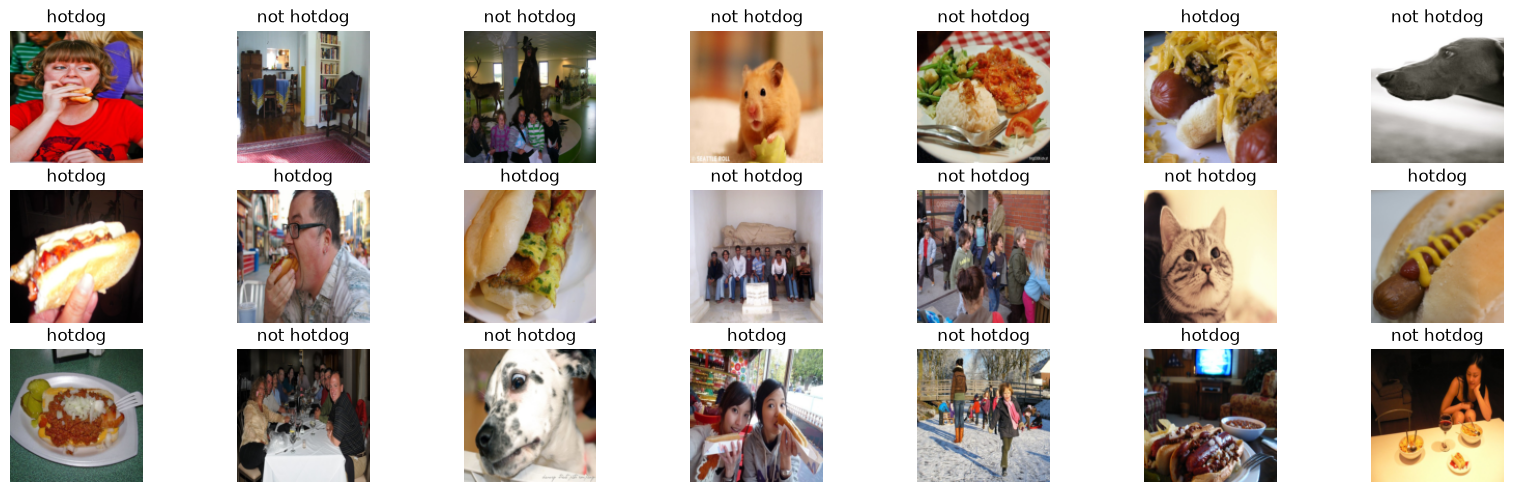

In [18]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


Now create a model and train it!


In [19]:
class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.convolutional = nn.Sequential(
            #2 Convolution layer that turns 3 RGB channels into 16 feature channels
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),

            #MaxPooling, from 128 to 64
            nn.MaxPool2d(2,2),

            #2 Convolution layers, going from 16 feature channels to 32
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),

            #MaxPooling, from 64 to 32
            nn.MaxPool2d(2,2),

            #2 Convolution layers, going from 32 feature channels to 64
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),

            #MaxPooling, from 32 to 16
            nn.MaxPool2d(2,2)
        )

        #Now we can build our fully connected network
        self.fully_connected = nn.Sequential(
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        x = self.convolutional(x)
        x = x.view(x.size(0), -1)
        x = self.fully_connected(x)
        return x


#### How did you decide on your architecture? Did you start out with something else? How/why did you decide to change it?

We started with using convolution layers, as to not have an overwhelming number of parameters. We originally started with one convolution layer, but decided to have 2 convolution layers, turning our initial 3 RGB channels into 16 feature channels, before we did the downsampling. We also used padding to ensure our picture remained with the same number of pixels, to make it easier for us to understand the dimensions. After each 2 convolution layers, we apply a MaxPooling, cutting down the pixel sample size by half, reducing spatial dimensions and allowing us to see more abstract objects (receptive field) the further we go into the model. 

We reduce this pixel sample size until 16x16, while doubling the feature channel capacity all the way to 64.

After these 6 convolution layers we take our 64 feature channels with our 16 by 16 images, having a 16384 values fully connected, before mapping them down into the final 2 outputs, Hotdog or NoHotdog.

In [20]:
#Initiate the model
model = Network().to(device)
criterion = nn.CrossEntropyLoss()
#Lets tart with the Adam optimizer, and later try the SGD
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

Network(
  (convolutional): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fully_connected): Sequential(
    (0): Linear(in_features=16384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_feat

In [21]:
num_epochs = 0

#Metrics
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    #TRAIN
    model.train()
    running_train_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    #VALIDATE
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {100*epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {100*epoch_val_acc:.2f}%")

In [22]:
#We have reached a plateau of 0.6929 of training loss. We will lower the learning rate and add weight decay.

In [23]:
model_v2 = Network().to(device)
criterion_v2 = nn.CrossEntropyLoss()

optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.0001, weight_decay=1e-4)

train_losses_v2, val_losses_v2 = [], []
train_acc_v2, val_acc_v2 = [], []

print("model_v2 initialized successfully.")

model_v2 initialized successfully.


In [24]:
num_epochs = 0

for epoch in range(num_epochs):
    #TRAIN
    model_v2.train()
    running_train_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train v2]"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer_v2.zero_grad()
        outputs = model_v2(images)
        loss = criterion_v2(outputs, labels)
        loss.backward()
        optimizer_v2.step()
        
        running_train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses_v2.append(epoch_train_loss)
    train_acc_v2.append(epoch_train_acc)
    
    #VALIDATION
    model_v2.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val v2]"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model_v2(images)
            loss = criterion_v2(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses_v2.append(epoch_val_loss)
    val_acc_v2.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {100*epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {100*epoch_val_acc:.2f}%")

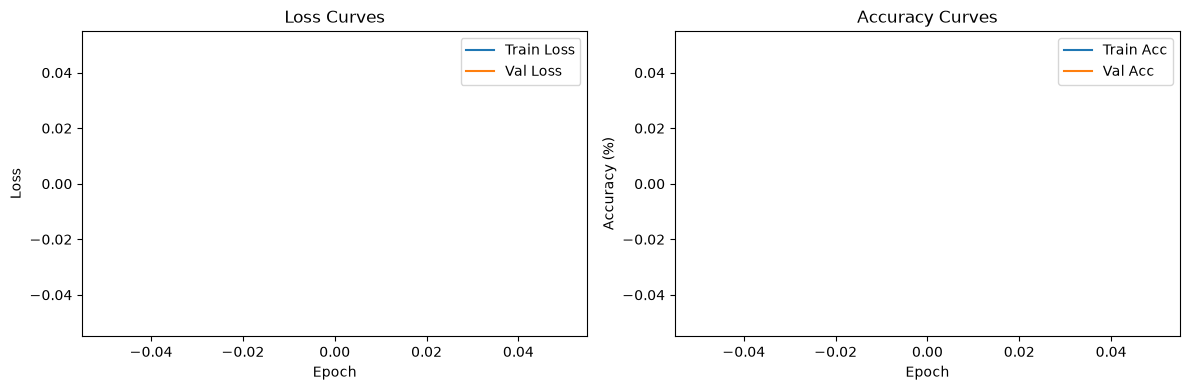

In [25]:
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses_v2, label='Train Loss')
plt.plot(val_losses_v2, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot([acc * 100 for acc in train_acc_v2], label='Train Acc')
plt.plot([acc * 100 for acc in val_acc_v2], label='Val Acc')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


Where we want it to go: You want training loss to steadily decrease toward zero, but the crucial rule is:$$\text{Validation Loss matters more than Training Loss}$$If training loss reaches $0.05$ (nearly $100\%$ train accuracy) while validation loss stops dropping and begins rising, the model is overfitting (memorizing pixels rather than learning general hotdog features). As long as validation loss decreases alongside training loss (like your run just did), learning is healthy.

This is a much better result. We broke the plateau down to ~0.5.
We also have minimum overfitting gap, because the training accuracy and validation accuracy are closely tracking eachother. This means the model os extracting real visual features, not just memorizing the training images.

In [26]:
import itertools

# Fix seeds
torch.manual_seed(42)

# Hyperparameter grid for Adam
lrs = [0.001, 0.0003, 0.0001]
weight_decays = [0.0, 1e-4]
num_epochs = 0

# Dictionary
adam_experiments = {}

for lr, wd in itertools.product(lrs, weight_decays):
    exp_name = f"lr={lr}_wd={wd}"
    print(f"\n{'='*45}")
    print(f"Running: Adam | {exp_name}")
    print(f"{'='*45}")
    torch.manual_seed(42)
    model = Network().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    
    for epoch in range(num_epochs):
        #TRAIN
        model.train()
        running_train_loss, correct_train, total_train = 0.0, 0, 0
        for images, labels in tqdm(train_loader, desc=f"{exp_name} | Ep {epoch+1}/{num_epochs} [Train]", leave=False):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)
            
        ep_train_loss = running_train_loss / total_train
        ep_train_acc = correct_train / total_train
        train_losses.append(ep_train_loss)
        train_accuracies.append(ep_train_acc)
        
        #VALIDATE
        model.eval()
        running_val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc=f"{exp_name} | Ep {epoch+1}/{num_epochs} [Val]", leave=False):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)
                
        ep_val_loss = running_val_loss / total_val
        ep_val_acc = correct_val / total_val
        val_losses.append(ep_val_loss)
        val_accuracies.append(ep_val_acc)
        
        print(f"Ep {epoch+1:02d} | Train Loss: {ep_train_loss:.4f}, Train Acc: {100*ep_train_acc:.1f}% | "
              f"Val Loss: {ep_val_loss:.4f}, Val Acc: {100*ep_val_acc:.1f}%")
        
    adam_experiments[exp_name] = {
        'lr': lr,
        'wd': wd,
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accuracies,
        'val_acc': val_accuracies,
        'best_val_acc': max(val_accuracies)
    }


Running: Adam | lr=0.001_wd=0.0


ValueError: max() iterable argument is empty

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

# Val Loss
plt.subplot(1, 3, 1)
for name, res in adam_experiments.items():
    style = '--' if res['wd'] > 0 else '-'
    plt.plot(res['val_loss'], linestyle=style, label=name)
plt.title('Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(fontsize=9)

# Val Acc
plt.subplot(1, 3, 2)
for name, res in adam_experiments.items():
    style = '--' if res['wd'] > 0 else '-'
    plt.plot([a * 100 for a in res['val_acc']], linestyle=style, label=name)
plt.title('Validation Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend(fontsize=9)

# Peak Acc
plt.subplot(1, 3, 3)
names = list(adam_experiments.keys())
best_accs = [adam_experiments[n]['best_val_acc'] * 100 for n in names]
bars = plt.barh(names, best_accs, color='tab:blue')
plt.xlim(65, 80) 
plt.title('Peak Validation Accuracy per Setting')
plt.xlabel('Accuracy (%)')
for bar in bars:
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.2f}%", va='center', fontsize=10)
plt.grid(axis='x', linestyle=':')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

lr_colors = {0.001: "#e9b108", 0.0003: '#2ca02c', 0.0001: "#5953c0"}

plt.figure(figsize=(18, 5))

# Val Loss
plt.subplot(1, 3, 1)
for res in adam_experiments.values():
    style = '--' if res['wd'] > 0 else '-'
    plt.plot(res['val_loss'], linestyle=style, color=lr_colors[res['lr']], linewidth=1.8)
plt.title('Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Val Acc
plt.subplot(1, 3, 2)
for res in adam_experiments.values():
    style = '--' if res['wd'] > 0 else '-'
    plt.plot([a * 100 for a in res['val_acc']], linestyle=style, color=lr_colors[res['lr']], linewidth=1.8)
plt.title('Validation Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)

legend_elements = [
    Line2D([0], [0], color='none', label=r'$\bf{Learning\ Rate:}$'),
    Line2D([0], [0], color=lr_colors[0.001], lw=2, label='0.001'),
    Line2D([0], [0], color=lr_colors[0.0003], lw=2, label='0.0003'),
    Line2D([0], [0], color=lr_colors[0.0001], lw=2, label='0.0001'),
    Line2D([0], [0], color='none', label=''),
    Line2D([0], [0], color='none', label=r'$\bf{Weight\ Decay:}$'),
    Line2D([0], [0], color='black', lw=1.8, linestyle='-', label='0.0 (Solid)'),
    Line2D([0], [0], color='black', lw=1.8, linestyle='--', label='1e-4 (Dashed)')
]
plt.subplot(1, 3, 1).legend(handles=legend_elements, loc='upper right', fontsize=8.5, framealpha=0.9)
plt.subplot(1, 3, 2).legend(handles=legend_elements, loc='lower right', fontsize=8.5, framealpha=0.9)

# Peak Acc
plt.subplot(1, 3, 3)
names = list(adam_experiments.keys())
clean_labels = [f"lr={adam_experiments[n]['lr']} | wd={adam_experiments[n]['wd']}" for n in names]
best_accs = [adam_experiments[n]['best_val_acc'] * 100 for n in names]
bar_colors = [lr_colors[adam_experiments[n]['lr']] for n in names]

bars = plt.barh(clean_labels, best_accs, color=bar_colors, edgecolor='black', alpha=0.85)
plt.xlim(68, 79)
plt.title('Peak Validation Accuracy per Setting')
plt.xlabel('Accuracy (%)')

for bar in bars:
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.2f}%", va='center', fontsize=9.5)
plt.grid(axis='x', linestyle=':')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

lr_colors = {0.001: "#e9b108", 0.0003: '#2ca02c', 0.0001: "#5953c0"}
max_epoch = 10

plt.figure(figsize=(18, 5))

# Val Loss
plt.subplot(1, 3, 1)
for res in adam_experiments.values():
    style = '--' if res['wd'] > 0 else '-'
    plt.plot(res['val_loss'][:max_epoch], linestyle=style, color=lr_colors[res['lr']], linewidth=1.8)
plt.title(f'Validation Loss Curves (First {max_epoch} Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Val Acc
plt.subplot(1, 3, 2)
for res in adam_experiments.values():
    style = '--' if res['wd'] > 0 else '-'
    plt.plot([a * 100 for a in res['val_acc'][:max_epoch]], linestyle=style, color=lr_colors[res['lr']], linewidth=1.8)
plt.title(f'Validation Accuracy Curves (First {max_epoch} Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)

legend_elements = [
    Line2D([0], [0], color='none', label=r'$\bf{Learning\ Rate:}$'),
    Line2D([0], [0], color=lr_colors[0.001], lw=2, label='0.001'),
    Line2D([0], [0], color=lr_colors[0.0003], lw=2, label='0.0003'),
    Line2D([0], [0], color=lr_colors[0.0001], lw=2, label='0.0001'),
    Line2D([0], [0], color='none', label=''),
    Line2D([0], [0], color='none', label=r'$\bf{Weight\ Decay:}$'),
    Line2D([0], [0], color='black', lw=1.8, linestyle='-', label='0.0 (Solid)'),
    Line2D([0], [0], color='black', lw=1.8, linestyle='--', label='1e-4 (Dashed)')
]
plt.subplot(1, 3, 1).legend(handles=legend_elements, loc='upper right', fontsize=8.5, framealpha=0.9)
plt.subplot(1, 3, 2).legend(handles=legend_elements, loc='lower right', fontsize=8.5, framealpha=0.9)

# Peak Acc (Calculated only over the first 10 epochs)
plt.subplot(1, 3, 3)
names = list(adam_experiments.keys())
clean_labels = [f"lr={adam_experiments[n]['lr']} | wd={adam_experiments[n]['wd']}" for n in names]
best_accs = [max(adam_experiments[n]['val_acc'][:max_epoch]) * 100 for n in names]
bar_colors = [lr_colors[adam_experiments[n]['lr']] for n in names]

bars = plt.barh(clean_labels, best_accs, color=bar_colors, edgecolor='black', alpha=0.85)
plt.xlim(68, 79)
plt.title(f'Peak Validation Accuracy (First {max_epoch} Epochs)')
plt.xlabel('Accuracy (%)')

for bar in bars:
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.2f}%", va='center', fontsize=9.5)
plt.grid(axis='x', linestyle=':')

plt.tight_layout()
plt.show()

## Data Augmentation and Batch Normalization

In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

size = 128
batch_size = 64
train_transform = transforms.Compose([
    transforms.Resize((size, size)),
    #transforms.RandomHorizontalFlip(p=0.5),
    #transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)

testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from PIL import Image

mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
raw_set = Hotdog_NotHotdog(train=True, transform=transforms.Resize((size, size)))

num_samples = 4
fig, axes = plt.subplots(num_samples, 2, figsize=(6, 3 * num_samples))

for i in range(num_samples):
    raw_img, label = raw_set[i]
    
    if not isinstance(raw_img, Image.Image):
        raw_img = transforms.ToPILImage()(raw_img)
    
    axes[i, 0].imshow(raw_img)
    axes[i, 0].set_title(f"Sample {i+1}: Original")
    axes[i, 0].axis('off')
    
    aug_tensor = train_transform(raw_img)
    img_unnorm = aug_tensor.numpy() * std + mean
    img_unnorm = np.clip(img_unnorm, 0, 1)
    img_augmented = np.transpose(img_unnorm, (1, 2, 0))
    
    axes[i, 1].imshow(img_augmented)
    axes[i, 1].set_title(f"Sample {i+1}: Augmented")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn

class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.convolutional = nn.Sequential(
            # 2 Convolution layers: 3 RGB channels to 16 feature channels + BatchNorm
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            # MaxPooling: 128 -> 64
            nn.MaxPool2d(2, 2),

            # 2 Convolution layers: 16 to 32 feature channels + BatchNorm
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # MaxPooling: 64 -> 32
            nn.MaxPool2d(2, 2),

            # 2 Convolution layers: 32 to 64 feature channels + BatchNorm
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # MaxPooling: 32 -> 16
            nn.MaxPool2d(2, 2)
        )

        # Fully connected network
        self.fully_connected = nn.Sequential(
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.convolutional(x)
        x = x.view(x.size(0), -1)
        x = self.fully_connected(x)
        return x

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm

# Initialize
model = Network().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 0

# Metrics tracking
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # TRAIN
    model.train()
    running_train_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # VALIDATE
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Val]"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {100*epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {100*epoch_val_acc:.2f}%")

We broke the 75% plateau, and the validation accuracy dropped to 0.4738. But, in the later stages, training loss continued to decline, but val loss didnt, it rose up again. This means we have overfitting. We need now to make the learning rate smaller in the later epochs, so when he is now close to the bottom of the valley, he doesnt overshoot his step and pass by the minimum. We can use a dropout, makinf some neurons zero in each pass, so it eliminates neurons dependence on one another, and this makes our dense layer, that has so many parameters, able to memorize noise and other incorrect assumptions. This while refining the data augmentation introducing zoom variation and the learning curve change will hopefully better our results. Lets see:

In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

size = 128
batch_size = 64
train_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(size, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)

testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

In [ ]:
import torch
import torch.nn as nn

class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.convolutional = nn.Sequential(
            # 2 Convolution layers: 3 RGB channels to 16 feature channels + BatchNorm
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            # MaxPooling: 128 -> 64
            nn.MaxPool2d(2, 2),

            # 2 Convolution layers: 16 to 32 feature channels + BatchNorm
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # MaxPooling: 64 -> 32
            nn.MaxPool2d(2, 2),

            # 2 Convolution layers: 32 to 64 feature channels + BatchNorm
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # MaxPooling: 32 -> 16
            nn.MaxPool2d(2, 2)
        )

        # Fully connected network
        self.fully_connected = nn.Sequential(
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.convolutional(x)
        x = x.view(x.size(0), -1)
        x = self.fully_connected(x)
        return x

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm

# Initialize
model = Network().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 0

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Metrics tracking
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # TRAIN
    model.train()
    running_train_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # VALIDATE
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Val]"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    current_lr = scheduler.get_last_lr()[0]
    
    print(f"Epoch {epoch+1:02d} | LR: {current_lr:.6f} |"
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {100*epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {100*epoch_val_acc:.2f}%")
    scheduler.step()

Ok, it was better but when the learning curve was halved, because the momentum was still carried, it made it overshoot in the first epochs after the change, making for the system to have a bigger val loss again until it recovered in the end. Lets also make this momentum parameteru slightly smaller. Lets change gradually the learning curve instead of halving it. Lets also add another dropout in the fully connected layer.

(Later I also implemented gradient clipping, to make sure there are no exploding gradients in the noise outlier batches, because I had a very big spike in val loss in epoch 6 when i ran this.)

In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

size = 32
batch_size = 64
train_transform = transforms.Compose([
    transforms.Resize((size, size)),
    #transforms.RandomHorizontalFlip(p=0.3),
    #transforms.RandomRotation(degrees=20),
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=(0.4,0.8)),
    #transforms.RandomResizedCrop(size, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)

testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

In [39]:
import torch
import torch.nn as nn

sizeRatio = size / 128

class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.convolutional = nn.Sequential(
            # 2 Convolution layers: 3 RGB channels to 16 feature channels + BatchNorm
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            # MaxPooling: 128 -> 64
            nn.MaxPool2d(2, 2),

            # 2 Convolution layers: 16 to 32 feature channels + BatchNorm
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # MaxPooling: 64 -> 32
            nn.MaxPool2d(2, 2),

            # 2 Convolution layers: 32 to 64 feature channels + BatchNorm
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # MaxPooling: 32 -> 16
            nn.MaxPool2d(2, 2)
        )

        # Fully connected network
        self.fully_connected = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(int(64 * 16 * 16 * sizeRatio * sizeRatio) , 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.convolutional(x)
        x = x.view(x.size(0), -1)
        x = self.fully_connected(x)
        return x

In [40]:
import torch
import torch.nn as nn
from tqdm import tqdm

# Initialize
model = Network().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.85, 0.999), weight_decay=1e-4)

num_epochs = 10

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

# Metrics tracking
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # TRAIN
    model.train()
    running_train_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # VALIDATE
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Val]"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    current_lr = scheduler.get_last_lr()[0]
    
    print(f"Epoch {epoch+1:02d} | LR: {current_lr:.6f} |"
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {100*epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {100*epoch_val_acc:.2f}%")
    scheduler.step()

Epoch 01/10 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01/10 [Val]: 100%|██████████| 30/30 [00:11<00:00,  2.52it/s]


Epoch 01 | LR: 0.001000 |Train Loss: 0.6744, Train Acc: 62.87% | Val Loss: 0.5867, Val Acc: 69.07%


Epoch 02/10 [Val]: 100%|██████████| 30/30 [00:12<00:00,  2.47it/s]


Epoch 02 | LR: 0.000976 |Train Loss: 0.5582, Train Acc: 72.94% | Val Loss: 0.7900, Val Acc: 70.41%


...

Epoch 08 | LR: 0.000214 |Train Loss: 0.4273, Train Acc: 81.14% | Val Loss: 0.5840, Val Acc: 73.47%


Epoch 09/10 [Val]: 100%|██████████| 30/30 [00:13<00:00,  2.23it/s]


Epoch 09 | LR: 0.000105 |Train Loss: 0.4115, Train Acc: 80.90% | Val Loss: 0.6101, Val Acc: 72.93%


Epoch 10/10 [Val]: 100%|██████████| 30/30 [00:15<00:00,  1.92it/s]

Epoch 10 | LR: 0.000034 |Train Loss: 0.4081, Train Acc: 83.05% | Val Loss: 0.5346, Val Acc: 75.56%


In [41]:
torch.save(model.state_dict(), 'best_hotdog_cnn_phase2_79.97.pth')
print("Model saved successfully!")

Model saved successfully!


Lets try one convolution layer per maxpooling to see if its a better model.